<a href="https://colab.research.google.com/github/karpat05/Taller-2-blade/blob/main/Entrega_Final_2_Corte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Módulo Experto:** Aprendizaje No Supervisado

**Tema central:** Segmentación de eventos sísmicos con K-Means y análisis de dimensionalidad con PCA
Este módulo práctico explora técnicas de aprendizaje no supervisado aplicadas a un conjunto de datos real de eventos sísmicos, con el objetivo de identificar patrones ocultos, segmentar terremotos según sus características físicas y de impacto percibido, y reducir la dimensionalidad para facilitar la visualización e interpretación.

**Objetivos del módulo**

Comprender el rol del aprendizaje no supervisado en la exploración de
datos sísmicos, especialmente cuando no se dispone de etiquetas confiables o se busca descubrir patrones ocultos en magnitud, profundidad, intensidad percibida (CDI/MMI) y significancia del evento.

Reconocer las ventajas y desafíos de aplicar técnicas no supervisadas a datos geofísicos, como la identificación de perfiles de terremotos con impacto similar, la detección de anomalías o la agrupación de eventos con características físicas coherentes, incluso en ausencia de niveles de alerta predefinidos.

Profundizar en el algoritmo K-Means aplicado a eventos sísmicos:
Comprender cómo agrupa terremotos según similitudes en sus atributos numéricos (magnitude, depth, cdi, mmi, sig).

Evaluar distintos métodos para elegir el número óptimo de clusters (k), como el método del codo y el coeficiente de silueta.

Analizar los centroides resultantes para interpretar qué tipo de sismos representa cada grupo (por ejemplo: “sismos superficiales de alta intensidad” vs. “sismos profundos de baja percepción”).

Dominar el Análisis de Componentes Principales (PCA) como herramienta para:
Reducir la dimensionalidad del conjunto de 5 variables físicas a 2 o 3 componentes interpretables.
Visualizar la estructura latente de los datos sísmicos en planos 2D/3D.

Evaluar cuánta información (varianza) se conserva tras la reducción y si esta facilita la separación de grupos.
Integrar PCA y K-Means en un flujo de trabajo coherente:
Aplicar K-Means tanto en el espacio original como en el espacio reducido por PCA.

Comparar la estabilidad y coherencia de los clusters.
Evaluar si la visualización post-PCA ayuda a validar o refinar la segmentación.

Relacionar los resultados del análisis no supervisado con la variable de alerta (alert) —aunque no se use durante el entrenamiento— para:
Validar intuitivamente si los clusters descubiertos coinciden con niveles de riesgo conocidos (green, yellow, orange, red).
Reflexionar sobre el potencial de estos métodos para automatizar o mejorar sistemas de alerta temprana.

Desarrollar actividades prácticas y evaluaciones formativas basadas en este dataset real, alineadas con los contenidos del examen parcial: selección de k, interpretación de componentes principales, escalado de variables, y crítica de resultados en contexto sísmico.

**1. El universo de los datos sísmicos sin etiquetar**

En monitoreo sísmico, los sensores generan continuamente grandes volúmenes de datos: magnitud, profundidad, intensidad percibida (CDI), intensidad instrumental (MMI) y métricas de significancia (sig). Sin embargo, la asignación de un nivel de alerta (como green, yellow, orange o red) no siempre está disponible en tiempo real, puede ser subjetiva, o depender de sistemas manuales que no escalan globalmente.

Etiquetar cada sismo con su nivel de riesgo correcto requiere expertos, validación en campo y tiempo — recursos escasos en regiones con alta actividad sísmica. Por eso, el aprendizaje no supervisado se convierte en una herramienta esencial: permite descubrir patrones intrínsecos en los eventos sísmicos sin depender de etiquetas predefinidas.

**Idea clave:** en lugar de predecir una alerta conocida (como haría un modelo supervisado), buscamos agrupar terremotos según su comportamiento físico y su impacto percibido, revelando perfiles naturales como:

Sismos profundos de baja percepción,
Eventos superficiales de alta intensidad,
Terremotos de magnitud elevada pero con bajo impacto local,
o eventos atípicos que podrían indicar fallas geológicas particulares.
**Ejemplo aplicado:** usando solo las variables magnitude, depth, cdi, mmi y sig, un algoritmo de agrupamiento puede identificar automáticamente un grupo de sismos que, aunque no tienen etiqueta, comparten características típicas de eventos de alto riesgo (magnitud > 7, poca profundidad, CDI ≥ 8). Estos clusters podrían servir como base para sistemas de alerta temprana automatizados o para priorizar respuestas en zonas vulnerables, incluso antes de que se emita una alerta oficial.

**Ventajas estratégicas destacadas**

**Descubrimiento de patrones ocultos en eventos sísmicos:**
Permite identificar perfiles naturales de terremotos que no son evidentes a simple vista.

**Ejemplo:** el algoritmo puede agrupar sismos con alta magnitud pero baja intensidad percibida (CDI), típicos de eventos profundos, versus sismos de magnitud moderada pero con CDI elevado, típicos de fallas cercanas a zonas urbanas — información crítica para priorizar respuestas de emergencia.

**Escalabilidad para monitoreo sísmico en tiempo real:**
Evita la dependencia de etiquetas manuales de alerta, que son lentas, subjetivas o inexistentes en muchas regiones.

**Ejemplo: **en redes globales de sensores (como las de USGS), millones de eventos pueden segmentarse automáticamente según su comportamiento físico (magnitude, depth, mmi, sig), facilitando la detección temprana de eventos de alto impacto sin intervención humana.

**Flexibilidad exploratoria para diseño de sistemas de alerta:**
Permite probar distintas hipótesis sobre qué combinación de variables define un “sismo peligroso”.

**Ejemplo:** un equipo de ingenieros puede comparar agrupaciones basadas solo en depth y cdi versus otras que incluyan sig, y evaluar cuál se alinea mejor con daños reales reportados, todo en cuestión de minutos.

**Retos Recurrentes**

**Validación subjetiva de los clusters sísmicos:**
No existe una “verdad absoluta” sobre cuántos tipos de terremotos existen, por lo que la interpretación de los grupos depende del contexto geológico y de riesgo.

**Ejemplo:** un cluster que mezcla sismos profundos de alta magnitud con sismos superficiales de baja intensidad podría considerarse “ruido” por un sismólogo, pero “evento de bajo riesgo” por un gestor de emergencias.

**Sensibilidad al preprocesamiento de variables físicas:**
Las escalas de las variables son muy distintas: magnitude (rango ~6–8.5), depth (0–700 km), sig (–130 a +130), etc. Sin escalado, una variable como depth puede dominar artificialmente la distancia euclidiana en K-Means.

**Ejemplo:** si no se normalizan las variables, un sismo a 600 km de profundidad podría parecer “muy diferente” de uno a 10 km, incluso si su impacto en superficie es similar.

**Elección del algoritmo según la geometría de los datos sísmicos:**
K-Means asume clusters esféricos y de tamaño similar, lo que puede no reflejar la realidad geofísica, donde los eventos pueden formar estructuras alargadas (ej. zonas de subducción) o estar dispersos.

**Ejemplo:** en regiones con fallas lineales, DBSCAN o algoritmos basados en densidad podrían identificar mejor agrupaciones espaciales coherentes, mientras que K-Means podría forzar divisiones artificiales.

**2. Tipologías dentro del aprendizaje no supervisado (aplicadas a eventos sísmicos)**

**Clustering (agrupamiento):**
Agrupar terremotos con características físicas e intensidades percibidas similares, sin usar la etiqueta de alerta.
**Ejemplo:** identificar clusters como “sismos superficiales de alta intensidad percibida” (poca profundidad, CDI ≥ 8, magnitud > 7) versus “sismos profundos de bajo impacto” (profundidad > 500 km, CDI ≈ 0–3), lo que puede ayudar a priorizar respuestas de emergencia o mejorar modelos de alerta automática.

**Reducción de dimensionalidad:**
Comprimir las cinco variables numéricas (magnitude, depth, cdi, mmi, sig) en un número menor de componentes que capturen la mayor parte de la variabilidad del comportamiento sísmico.
**Ejemplo:** usar PCA para proyectar los eventos en un plano 2D donde el eje 1 represente una combinación de magnitud e intensidad percibida y el eje 2 refleje profundidad y significancia, facilitando la visualización de patrones o la preparación de datos para modelos posteriores.

Detección de anomalías:
Identificar terremotos que se desvían significativamente del comportamiento típico del conjunto, lo que podría indicar errores de medición, eventos geológicamente atípicos o situaciones de alto riesgo no capturadas por sistemas convencionales.
**Ejemplo:** un sismo con magnitud 7.5, profundidad de 10 km, pero CDI = 0 (ningún reporte de percepción) podría ser una anomalía digna de revisión, ya que contradice la expectativa de alto impacto en superficie.

**Recomendación basada en similitud (en contexto geofísico):**
Aunque no se usan “recomendaciones” en el sentido tradicional, este enfoque permite asociar eventos sísmicos similares para transferir conocimiento.
**Ejemplo:** dado un nuevo sismo sin alerta asignada, encontrar los eventos históricos más cercanos en el espacio de características (magnitude, depth, cdi, etc.) y usar sus niveles de alerta como referencia aproximada — una forma de vecino más cercano no supervisado útil en sistemas de alerta temprana.

**3. Flujo general de un proyecto no supervisado (aplicado a eventos sísmicos)**

**Exploración y limpieza:**
Analizar la distribución de variables clave (magnitude, depth, cdi, mmi, sig) para detectar valores faltantes, outliers geofísicamente improbables o inconsistencias (por ejemplo, cdi > 10 o depth < 0). En este dataset balanceado, aunque no hay valores nulos explícitos, sí existen registros con cdi = 0 o mmi muy bajos en sismos de alta magnitud, lo que puede indicar zonas remotas o fallas en los reportes — información relevante para decidir si mantener o transformar esos datos.

**Preprocesamiento:**
Escalar todas las variables numéricas con StandardScaler o MinMaxScaler, ya que operan en escalas muy distintas (ej. magnitude entre 6.5–8.6, depth entre 0–700 km, sig entre –130 y +130). No se requiere codificación, ya que todas las variables son numéricas. Se descarta intencionalmente la columna alert para mantener un enfoque no supervisado, aunque se reserva para validación posterior.

**Experimentación:**
Probar distintas configuraciones de K-Means (valores de k entre 2 y 8), evaluar con el método del codo y el coeficiente de silueta, y comparar con alternativas como DBSCAN (útil si se sospechan estructuras no esféricas, como en zonas de subducción). Paralelamente, aplicar PCA con 2 o 3 componentes para visualización, y probar si agrupar en el espacio reducido mejora la coherencia de los clusters.

**Interpretación y validación:**
Analizar los centroides de cada cluster para identificar perfiles sísmicos: por ejemplo, un cluster con alta magnitude, poca depth y alto cdi podría corresponder a “sismos peligrosos cercanos a zonas pobladas”. Luego, contrastar estos grupos con la variable alert (aunque no usada en el entrenamiento) para verificar si los clusters se alinean con niveles de riesgo conocidos (green, yellow, orange, red). También se usan visualizaciones 2D/3D post-PCA para inspeccionar la separación entre grupos.

**Comunicación y despliegue:**
Documentar los perfiles de terremotos descubiertos y proponer reglas automáticas de alerta temprana basadas en pertenencia a clusters de alto riesgo. Por ejemplo: “Si un nuevo sismo cae en el cluster 3 (magnitud > 7, profundidad < 20 km, CDI ≥ 8), activar protocolo de alerta naranja”. Estos resultados pueden integrarse en un dashboard de monitoreo sísmico para equipos de emergencia, facilitando decisiones rápidas sin depender de etiquetas manuales en tiempo real.

**4. Preparación del entorno**

Ejecuta la siguiente celda para cargar las bibliotecas esenciales que utilizaremos a lo largo del taller. Estas herramientas nos permitirán explorar, preprocesar, agrupar y visualizar los eventos sísmicos del dataset earthquake_alert_balanced_dataset.csv.

Dado que trabajaremos con variables físicas como magnitud, profundidad, intensidad percibida (CDI), intensidad instrumental (MMI) y significancia (sig), usaremos:

pandas y numpy para manipulación de datos numéricos.
scikit-learn para escalado, K-Means, PCA y métricas de evaluación (silueta, inercia).

matplotlib y seaborn para visualizaciones estáticas de distribuciones, matrices de correlación y proyecciones 2D/3D post-PCA.
plotly (opcional pero recomendado) para visualizaciones interactivas que faciliten la exploración de clusters en múltiples dimensiones.

In [ ]:
# Bibliotecas esenciales para el análisis de datos sísmicos no supervisado
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y algoritmos de aprendizaje no supervisado
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Configuración visual para análisis exploratorio y visualización de clusters sísmicos
plt.style.use('seaborn-v0_8')
sns.set_palette('tab10')

# Semilla para reproducibilidad en inicializaciones aleatorias (K-Means, etc.)
np.random.seed(42)

# Nota: este entorno está diseñado para analizar eventos sísmicos a partir de las variables:
# - magnitude: magnitud del sismo
# - depth: profundidad del hipocentro (km)
# - cdi: Community Decimal Intensity (impacto percibido)
# - mmi: Modified Mercalli Intensity (intensidad instrumental)
# - sig: significancia del evento
# La columna 'alert' se utilizará únicamente para validación posterior, no en el entrenamiento.

**5. Ingesta de datos**

En este módulo trabajaremos con el dataset earthquake_alert_balanced_dataset.csv, que contiene eventos sísmicos reales registrados por sistemas de monitoreo global. Aunque incluye una columna de alerta (alert), la trataremos como información externa de validación, no como variable objetivo, para mantener un enfoque puramente no supervisado.

**El conjunto incluye las siguientes variables numéricas clave para el análisis:**

**magnitude:** magnitud del sismo (escala de momento o Richter).

**depth:** profundidad del hipocentro en kilómetros.

**cdi:** Community Decimal Intensity, medida subjetiva del impacto percibido por la población.

**mmi:** Modified Mercalli Intensity, escala estandarizada de intensidad sísmica.

**sig:** Significance, valor compuesto que refleja la relevancia del evento según múltiples factores geofísicos.

In [ ]:
# --- Carga del dataset sísmico real ---
# Seleccionamos únicamente las variables numéricas relevantes para el análisis no supervisado:
# magnitude, depth, cdi, mmi, sig
# La columna 'alert' se excluye intencionalmente del modelado (solo se usará para validación posterior).

df = pd.read_csv('earthquake_alert_balanced_dataset.csv')
X = df[['magnitude', 'depth', 'cdi', 'mmi', 'sig']].copy()

print('Dimensiones del conjunto de datos sísmicos:', X.shape)
X.head()

Dimensiones del conjunto de datos sísmicos: (1300, 5)


,magnitude,depth,cdi,mmi,sig
0,7.0,14.0,8.0,7.0,0.0
1,6.9,25.0,4.0,4.0,-33.0
2,7.0,579.0,3.0,3.0,-13.0
3,7.3,37.0,5.0,5.0,65.0
4,6.6,624.0,0.0,2.0,-98.0


**6. Exploración inicial**
Antes de aplicar técnicas de aprendizaje no supervisado, es fundamental comprender la distribución, escala y relaciones entre las variables sísmicas del dataset. Esto incluye:

Estadísticas descriptivas (magnitude, depth, cdi, mmi, sig) para identificar rangos, asimetrías o valores extremos.
Por ejemplo: ¿la depth tiene una distribución bimodal (sismos superficiales vs. profundos)? ¿la cdi (intensidad percibida) está sesgada hacia valores bajos, indicando que muchos sismos ocurren en zonas remotas?
Histogramas y diagramas de caja para visualizar la forma de cada variable.

Es común que cdi y mmi presenten muchos valores bajos (0–3) y una cola larga hacia intensidades altas (7–10), lo que refleja la naturaleza rara de eventos de alto impacto.

Matriz de correlación para detectar redundancias.
Por ejemplo: cdi y mmi suelen estar altamente correlacionadas (ambas miden intensidad, una subjetiva y otra instrumental). Incluir ambas en PCA o K-Means sin considerar esta relación puede sesgar los resultados hacia la dimensión de “intensidad”, opacando el efecto de magnitude o depth.

Identificación de variables con baja varianza: aunque en este dataset todas las variables parecen informativas, es importante verificar si alguna tiene varianza cercana a cero (poco probable aquí, pero crítico en otros contextos).

Documentación de decisiones: dado que este dataset ya está balanceado y no contiene valores nulos, no se requiere imputación. Sin embargo, se debe registrar explícitamente que:
La columna alert se excluye del modelado no supervisado.
Todas las variables numéricas se escalarán antes de aplicar K-Means o PCA, debido a sus unidades y rangos muy distintos.

,count,mean,std,min,25%,50%,75%,max
magnitude,1300.0,7.061008,0.423738,6.5,6.7,7.0,7.3,8.6
depth,1300.0,50.321538,104.348286,2.0,12.0,19.0,38.0,670.0
cdi,1300.0,6.976154,2.244875,0.0,6.0,8.0,8.0,9.0
mmi,1300.0,6.939231,1.354774,1.0,6.0,7.0,8.0,9.0
sig,1300.0,-9.749231,62.245214,-128.0,-54.0,-7.0,31.0,127.0


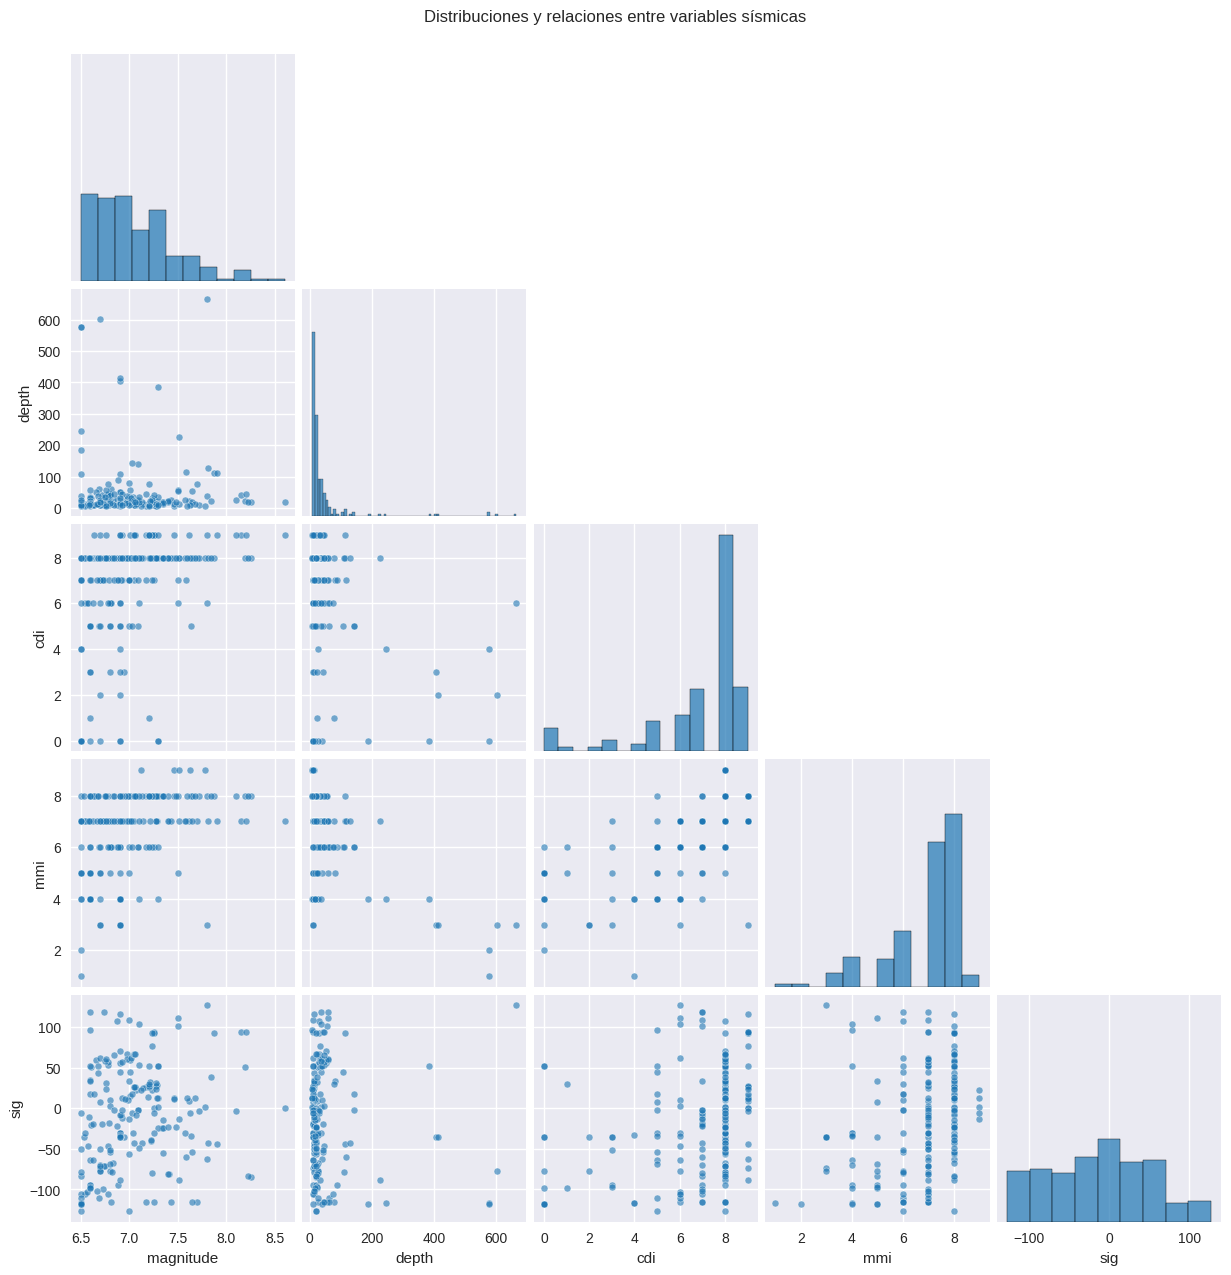

In [ ]:
# --- Exploración estadística y visual de las variables sísmicas ---
# Mostrar estadísticas descriptivas de las 5 variables clave:
# magnitude, depth, cdi, mmi, sig
display(X.describe().T)

# Visualizar relaciones entre pares de variables con un subconjunto representativo
# (máximo 200 observaciones para agilizar la visualización)
sample_size = min(200, len(X))
sns.pairplot(
    X.sample(sample_size, random_state=42),
    corner=True,
    plot_kws={'alpha': 0.6, 's': 25},
    diag_kws={'alpha': 0.7}
)
plt.suptitle('Distribuciones y relaciones entre variables sísmicas', y=1.02)
plt.show()

**6.1 Matriz de correlación enriquecida**

Para comprender mejor las relaciones entre las variables físicas y perceptuales de los sismos, construimos una matriz de correlación de Pearson a partir de las cinco características numéricas del dataset:

**magnitude:** magnitud del evento
**depth:** profundidad del hipocentro (km)
**cdi:** Community Decimal Intensity (impacto percibido por la población)
**mmi:** Modified Mercalli Intensity (intensidad instrumental estimada)
**sig:** Significance, métrica compuesta de relevancia del sismo

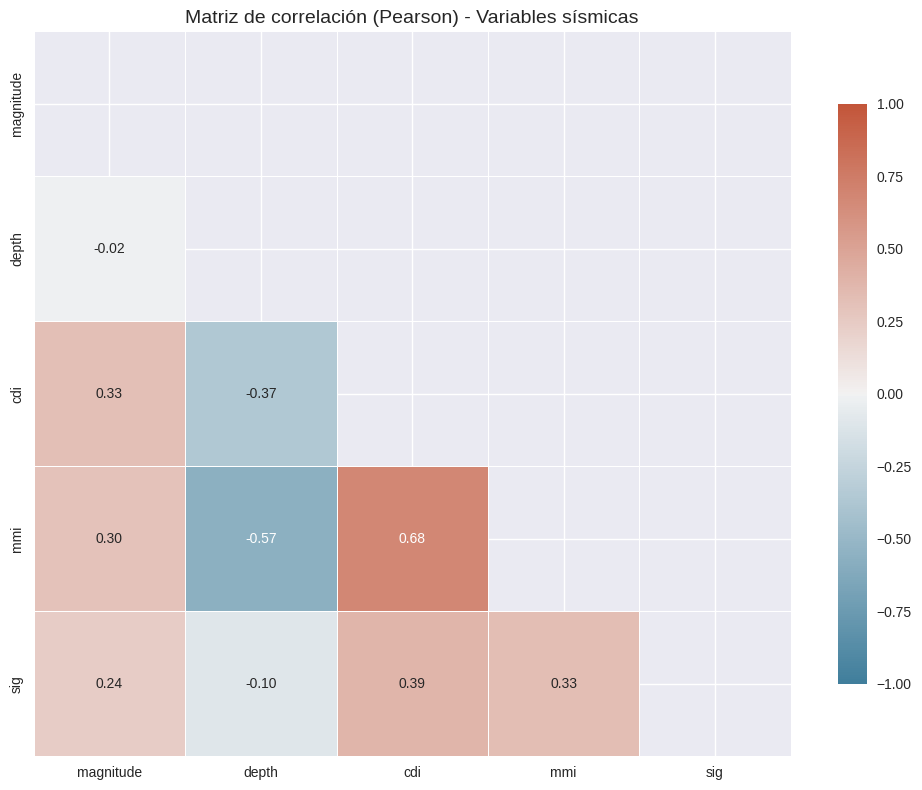

Pares de variables sísmicas con mayor correlación (|r|):


,variable_1,variable_2,correlacion,correlacion_abs
7,cdi,mmi,0.677894,0.677894
5,depth,mmi,-0.566402,0.566402
8,cdi,sig,0.387195,0.387195
4,depth,cdi,-0.367134,0.367134
9,mmi,sig,0.330218,0.330218
1,magnitude,cdi,0.325690,0.325690
2,magnitude,mmi,0.302139,0.302139
3,magnitude,sig,0.241131,0.241131
6,depth,sig,-0.099639,0.099639
0,magnitude,depth,-0.015459,0.015459


In [ ]:
# --- Matriz de correlación enriquecida: variables sísmicas ---
# Analizamos la relación entre magnitud, profundidad, intensidad percibida (CDI),
# intensidad instrumental (MMI) y significancia (sig).

corr = X.corr(method='pearson')
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    annot=True,
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriz de correlación (Pearson) - Variables sísmicas', fontsize=14)
plt.tight_layout()
plt.show()

# Extraer las 10 correlaciones más fuertes (en valor absoluto)
tri_upper = np.triu_indices_from(corr, k=1)
top_correlaciones = (
    pd.DataFrame({
        'variable_1': corr.columns[tri_upper[0]],
        'variable_2': corr.columns[tri_upper[1]],
        'correlacion': corr.values[tri_upper]
    })
    .assign(correlacion_abs=lambda df: df['correlacion'].abs())
    .sort_values('correlacion_abs', ascending=False)
    .head(10)
)

# Mostrar las correlaciones más relevantes
print("Pares de variables sísmicas con mayor correlación (|r|):")
display(top_correlaciones)

**7. Preprocesamiento y escalado**
El escalado es esencial en este análisis porque las variables sísmicas operan en escalas muy distintas:

**magnitude:** rango típico entre 6.5 y 8.6

**depth:** profundidad en kilómetros, desde 0 hasta más de 700 km

**cdi y mmi:** intensidades percibidas e instrumentales, en escalas discretas de 0 a 10

**sig (significance):** valor compuesto que puede variar entre –130 y +130
Dado que K-Means se basa en distancias euclidianas y PCA busca direcciones de máxima varianza, una variable como depth o sig podría dominar artificialmente los resultados si no se normaliza.

**Ejemplo práctico en contexto sísmico:**
Sin escalado, un sismo a 600 km de profundidad parecería “muy diferente” de uno a 10 km, incluso si su magnitud e intensidad son similares. Tras el escalado, la agrupación reflejará mejor combinaciones físicamente coherentes, como “sismos superficiales de alto impacto” versus “eventos profundos de baja percepción”.

In [ ]:
# Escalado de las variables sísmicas para análisis no supervisado
# Las variables (magnitude, depth, cdi, mmi, sig) operan en escalas muy distintas.
# StandardScaler las transforma a media ≈ 0 y desviación estándar ≈ 1,
# asegurando que ninguna variable domine artificialmente K-Means o PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificación: todas las variables deben tener media ≈ 0 y std ≈ 1
print('Media aproximada tras escalado (debe ser ~0):', X_scaled.mean(axis=0))
print('Desviación estándar aproximada tras escalado (debe ser ~1):', X_scaled.std(axis=0))

Media aproximada tras escalado (debe ser ~0): [ 4.59119922e-16  0.00000000e+00 -2.18628534e-16  8.74514136e-17
 -4.37257068e-17]
Desviación estándar aproximada tras escalado (debe ser ~1): [1. 1. 1. 1. 1.]


**8. Fundamentos teóricos (K-Means aplicado a eventos sísmicos)**

**El objetivo de K-Means en este contexto es minimizar la inercia:** la suma de las distancias cuadradas entre cada sismo y el centroide del grupo al que pertenece. Esto permite identificar perfiles sísmicos coherentes, como “sismos superficiales de alto impacto” o “eventos profundos de baja percepción”, donde los miembros de cada grupo comparten características físicas similares.

El algoritmo requiere definir de antemano el número de clusters K. **Por ejemplo, podríamos preguntarnos:**
→ ¿Es útil distinguir 3 tipos de sismos (bajo, medio y alto riesgo)?
→ ¿O son necesarios 4 perfiles para capturar la diferencia entre eventos profundos y superficiales de alta magnitud?

**K-Means opera mediante una iteración alternada de dos pasos:**

**Asignación:** cada sismo se asigna al centroide más cercano en el espacio de características (magnitude, depth, cdi, mmi, sig).
**Actualización:** los centroides se recalculan como el promedio de todas las variables de los sismos asignados a ese grupo.
Este proceso se repite hasta que los centroides ya no cambian significativamente.
La inicialización de los centroides influye fuertemente en la calidad del resultado. Por eso usamos k-means++, que distribuye los centroides iniciales de forma estratégica (evitando que todos comiencen en sismos similares, por ejemplo, solo en eventos profundos). Esto reduce el riesgo de converger a una solución subóptima.

**Sin embargo, K-Means tiene limitaciones importantes en este dominio:**

Es sensible a outliers, como un sismo con cdi = 0 pero magnitude = 8.0, que podría distorsionar el centroide de un grupo.
Asume que los clusters son esféricos y de tamaño similar, lo que puede no reflejar la realidad geofísica: por ejemplo, los sismos en zonas de subducción suelen formar estructuras alargadas o curvas en el espacio de profundidad-magnitud.
En esos casos, alternativas como DBSCAN (basado en densidad) o clustering jerárquico podrían capturar mejor la geometría natural de los datos.

**8.1 Pseudocódigo resumido (K-Means aplicado a sismos)**

Seleccionar K centroides iniciales en el espacio de características sísmicas (magnitude, depth, cdi, mmi, sig).
**Ejemplo: escoger K sismos representativos como semillas:** uno superficial de alta intensidad, otro profundo de baja percepción y otro de magnitud extrema, usando la estrategia k-means++ para evitar inicializaciones sesgadas.

Asignar cada sismo al centroide más cercano, usando la distancia euclidiana en el espacio escalado de las 5 variables.
**Ejemplo:**un terremoto con magnitude=7.2, depth=15 km, cdi=9 se asignará al cluster cuyo centroide represente mejor los “sismos cercanos de alto impacto”.

Recalcular cada centroide como el promedio (media) de todas las variables de los sismos asignados a ese grupo.
Ejemplo: el nuevo centroide del cluster de “sismos peligrosos” podría ser: magnitude=7.4, depth=18 km, cdi=8.7, mmi=7.9, sig=45.

**Repetir los pasos 2 y 3 hasta convergencia:**
Cuando los centroides ya no cambian significativamente (movimiento < umbral),
O se alcanza el número máximo de iteraciones.
Ejemplo: el algoritmo se detiene cuando los centroides de los perfiles sísmicos se estabilizan, indicando que los grupos han alcanzado una configuración coherente.

**9. Selección de K:**
método del codo y coeficiente de silueta
Para identificar el número óptimo de perfiles sísmicos, realizamos un barrido de valores de K (por ejemplo, de 2 a 10) y evaluamos dos métricas complementarias:

**Inercia (WCSS):** suma de las distancias al cuadrado de cada sismo a su centroide. Disminuye a medida que aumenta K, pero buscamos el punto donde la reducción se desacelera (el “codo”).

**Coeficiente de silueta:** mide cuán similar es un sismo a su propio cluster en comparación con otros clusters. Valores cercanos a 1 indican agrupaciones coherentes y bien separadas.

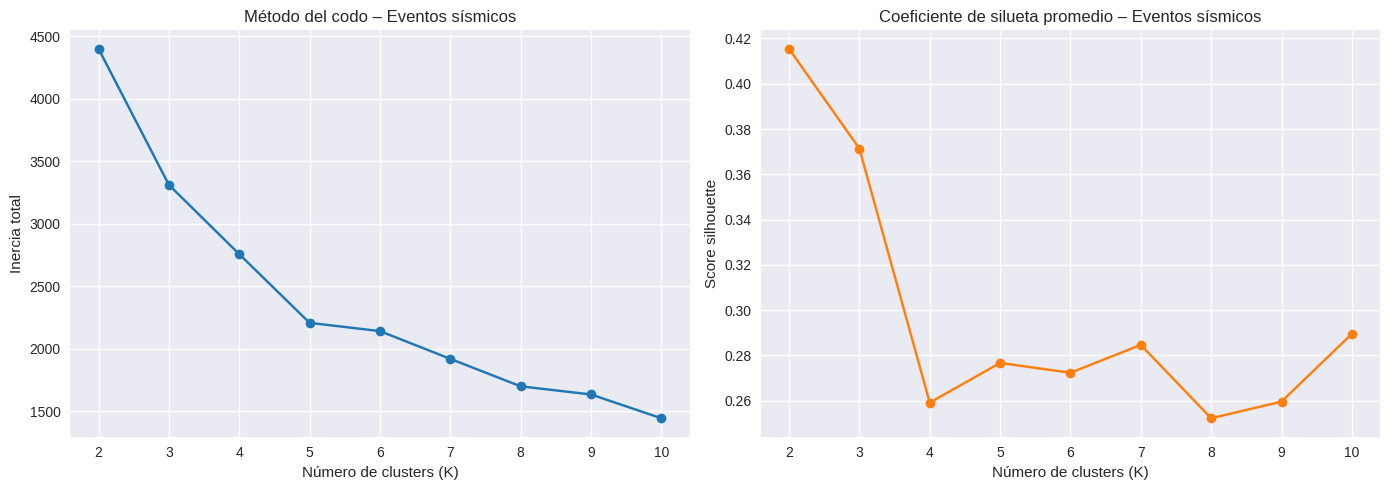

In [ ]:
# Evaluación de K para agrupamiento de eventos sísmicos
# Buscamos el número óptimo de perfiles sísmicos (ej. sismos profundos de baja percepción,
# sismos superficiales de alto impacto, etc.)

Ks = range(2, 11)
inertias = []
silhouette_scores = []

for k in Ks:
    modelo = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    etiquetas = modelo.fit_predict(X_scaled)
    inertias.append(modelo.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, etiquetas))

# Visualización de métricas para selección de K
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(Ks, inertias, marker='o')
ax[0].set_title('Método del codo – Eventos sísmicos')
ax[0].set_xlabel('Número de clusters (K)')
ax[0].set_ylabel('Inercia total')

ax[1].plot(Ks, silhouette_scores, marker='o', color='tab:orange')
ax[1].set_title('Coeficiente de silueta promedio – Eventos sísmicos')
ax[1].set_xlabel('Número de clusters (K)')
ax[1].set_ylabel('Score silhouette')

plt.tight_layout()
plt.show()

**En este análisis, buscamos identificar perfiles naturales de terremotos sin usar la etiqueta alert.**

El método del codo nos indica a partir de qué K la reducción en inercia se vuelve marginal.
El coeficiente de silueta nos dice cuán cohesivos y separados están los clusters.
Un buen equilibrio suele encontrarse en K = 3 o K = 4, lo que podría corresponder a:

Sismos profundos, baja percepción
Sismos superficiales, impacto moderado
Eventos de alto riesgo (alta magnitud + poca profundidad + alta CDI)
(Opcional) Sismos atípicos o de magnitud extrema en zonas remotas

**10. Entrenamiento final de K-Means**
Con base en el análisis del método del codo y el coeficiente de silueta, seleccionamos el valor óptimo de K (por ejemplo, K = 3 o K = 4) que mejor equilibra cohesión interna y separación entre grupos de eventos sísmicos.

**Entrenamos el modelo definitivo de K-Means con ese valor y analizamos:**

**Los centroides:** representan el “perfil promedio” de cada cluster en las variables originales (magnitude, depth, cdi, mmi, sig).

**El tamaño de cada grupo:** indica cuán frecuentes son esos perfiles en el conjunto de datos.

**Ejemplo guiado en contexto sísmico:**
Si K = 3, podríamos interpretar los clusters como:

**Cluster 0:** Sismos profundos de baja percepción → alta depth (>400 km), baja cdi (≤2), magnitud moderada.
**Cluster 1:** Sismos superficiales de impacto moderado → poca depth (<30 km), cdi entre 5–7, magnitude ~6.5–7.0.
**Cluster 2:** Eventos de alto riesgo → poca depth, alta magnitude (>7.5), cdi ≥ 8, mmi ≥ 7.
Si K = 4, podría emerger un cuarto grupo como sismos extremos en zonas remotas (alta magnitude pero cdi = 0), útil para detectar eventos con potencial de tsunami o fallas no instrumentadas.

In [ ]:
# Entrenamiento final de K-Means con el número óptimo de clusters (K)
# Basado en el análisis del método del codo y el coeficiente de silueta,
# seleccionamos K = 3 para identificar perfiles sísmicos coherentes.

best_k = 3  # Ajusta este valor si tu análisis sugiere otro K óptimo (ej. 4)
kmeans = KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Añadimos la asignación de clusters al dataset original para análisis e interpretación
resultado = X.copy()
resultado['cluster'] = clusters

# Los centroides están en el espacio escalado; los convertimos a un DataFrame legible
centroides_escalados = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns,
    index=[f'Cluster {i}' for i in range(best_k)]
)

# Mostrar tamaño de cada grupo (¿cuán frecuentes son estos perfiles sísmicos?)
print('Tamaño por cluster (frecuencia de perfiles sísmicos):')
display(resultado['cluster'].value_counts().sort_index())

print('\nCentroides en espacio escalado (valores estandarizados):')
display(centroides_escalados)

# Opcional: para interpretar en unidades originales, puedes desescalar los centroides:
# centroides_originales = scaler.inverse_transform(kmeans.cluster_centers_)
# centroides_orig = pd.DataFrame(centroides_originales, columns=X.columns, index=centroides_escalados.index)
# print('\nCentroides en unidades originales (para interpretación física):')
# display(centroides_orig)

Tamaño por cluster (frecuencia de perfiles sísmicos):


,count
cluster,
0,948
1,307
2,45



Centroides en espacio escalado (valores estandarizados):


,magnitude,depth,cdi,mmi,sig
Cluster 0,0.259333,-0.202103,0.443095,0.422648,0.326032
Cluster 1,-0.757392,-0.090052,-1.099821,-0.912421,-0.926974
Cluster 2,-0.296175,4.872003,-1.831313,-2.679057,-0.544396


**Con K = 3, es probable que los clusters representen:**

**Cluster 0:** Sismos profundos, baja percepción → alta depth, baja cdi/mmi.

**Cluster 1:** Sismos superficiales de impacto moderado → poca depth, magnitude media, cdi intermedia.

**Cluster 2:** Eventos de alto riesgo → poca depth, alta magnitude, cdi ≥ 8.

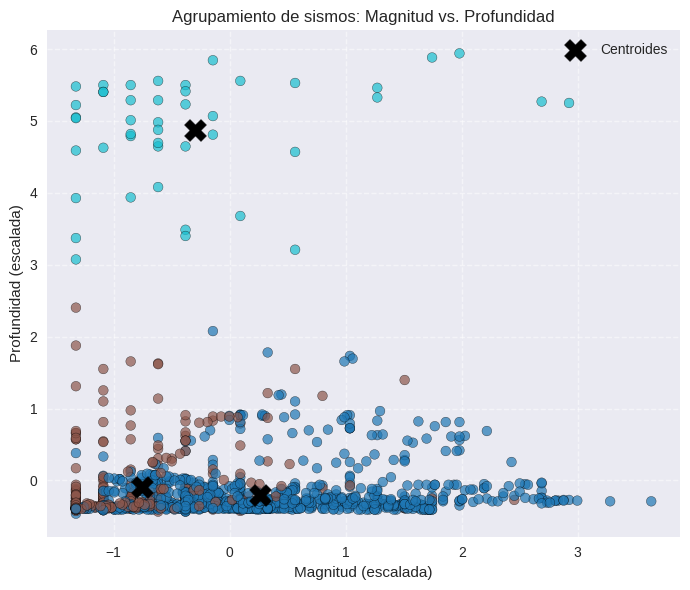

In [ ]:
# Visualización de clusters en el plano de las dos primeras variables sísmicas:
# Magnitud vs. Profundidad (las dos primeras columnas del dataset)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_scaled[:, 0],  # magnitude (escalada)
    X_scaled[:, 1],  # depth (escalada)
    c=clusters,
    cmap='tab10',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

# Centroides en el mismo espacio
ax.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c='black',
    marker='X',
    label='Centroides'
)

ax.set_xlabel('Magnitud (escalada)')
ax.set_ylabel('Profundidad (escalada)')
ax.set_title('Agrupamiento de sismos: Magnitud vs. Profundidad')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**10.1 Análisis interpretativo**

Para entender el significado físico de cada cluster, comparamos las medias de magnitude, depth, cdi, mmi y sig dentro de cada grupo con las medias globales del conjunto completo. Esto permite identificar qué variables definen a cada perfil sísmico.

**Ejemplo:** si un cluster tiene una depth promedio de 15 km (frente a una media global de 200 km) y un cdi de 8.5 (vs. media global de 5.2), podemos inferir que agrupa sismos superficiales de alto impacto percibido.

**Etiquetamos cada cluster con descriptores geofísicamente significativos, basados en sus rasgos distintivos:**

**Cluster 0:** Sismos profundos, baja percepción
→ Alta depth (>400 km), baja cdi (≤2), magnitude moderada.

**Cluster 1:** Sismos superficiales, impacto moderado
→ Poca depth (<30 km), cdi entre 5–7, magnitude ~6.5–7.0.

**Cluster 2:** Eventos de alto riesgo
→ Poca depth, alta magnitude (>7.5), cdi ≥ 8, mmi ≥ 7.

**Finalmente, relacionamos esta segmentación con decisiones operativas en gestión de riesgos:**

Los sismos del Cluster 2 podrían activar automáticamente protocolos de alerta naranja o roja, incluso antes de que se emita una alerta oficial.

El Cluster 0 podría descartarse rápidamente en sistemas de monitoreo en tiempo real, ya que su bajo impacto percibido sugiere riesgo mínimo para zonas pobladas.

El Cluster 1 merece seguimiento adicional: aunque no son extremos, su proximidad a la superficie los hace candidatos a causar daños locales, especialmente en infraestructuras vulnerables.

Este enfoque permite transformar un modelo no supervisado en una herramienta de apoyo a la toma de decisiones en contextos de emergencia, monitoreo sísmico automático o priorización de recursos.

In [ ]:
# Perfil promedio de cada cluster: ¿qué tipo de sismo representa cada grupo?
# Las columnas reflejan las características físicas e intensidades típicas por cluster.

perfil_sismico = resultado.groupby('cluster').mean(numeric_only=True)
display(perfil_sismico)

,magnitude,depth,cdi,mmi,sig
cluster,,,,,
0,7.170854,29.240506,7.970464,7.511603,10.536920
1,6.740195,40.928339,4.508143,5.703583,-67.426710
2,6.935556,558.511111,2.866667,3.311111,-43.622222


Este cuadro muestra el "sismo promedio" de cada cluster.

**Por ejemplo: **

Un cluster con alta magnitude, baja depth, y alta cdi/mmi corresponde a eventos superficiales de alto impacto (posible alerta roja/naranja).

Un cluster con alta depth y baja cdi representa sismos profundos de baja percepción, típicos en zonas de subducción.

Un cluster con magnitud moderada, profundidad intermedia y intensidad media podría asociarse a eventos de riesgo moderado.

**11. Evaluar la calidad del clustering**

Aunque no utilicemos la etiqueta alert durante el modelado (enfoque no supervisado), podemos evaluar la calidad de los clusters obtenidos mediante métricas internas que miden cohesión y separación en el espacio de características sísmicas (magnitude, depth, cdi, mmi, sig):

**Silhouette score:**
Mide el equilibrio entre cuán cercanos están los sismos dentro de su cluster y cuán lejos están de los sismos en otros clusters.
**Ejemplo:** un puntaje de 0.50–0.60 sugiere que los perfiles sísmicos (como “sismos profundos de baja percepción” vs. “eventos superficiales de alto impacto”) están razonablemente bien separados.

**Índice de Calinski-Harabasz:**
Compara la dispersión entre clusters con la dispersión dentro de los clusters. Valores más altos indican agrupaciones más compactas y bien separadas.
**Ejemplo:** un valor alto (>500) refuerza que los centroides representan perfiles físicamente distintos (por ejemplo, uno con alta depth y otro con alta cdi).

**Índice de Davies-Bouldin:**
Calcula la similitud promedio entre cada cluster y su vecino más parecido. Menor es mejor: valores cercanos a 0.8 o menos indican que los perfiles sísmicos no se solapan significativamente.

Estas métricas nos permiten validar que los clusters descubiertos no son artefactos aleatorios, sino estructuras coherentes en el comportamiento físico de los terremotos, lo que respalda su uso en aplicaciones como sistemas de alerta temprana automatizados o estudios geológicos exploratorios.

In [ ]:
# Evaluación de la calidad del agrupamiento de eventos sísmicos (sin usar la etiqueta 'alert')

print('Silhouette Score (cohesión y separación):', silhouette_score(X_scaled, clusters))
print('Índice de Calinski-Harabasz (mayor = clusters más separados):', calinski_harabasz_score(X_scaled, clusters))
print('Índice de Davies-Bouldin (menor = clusters menos similares):', davies_bouldin_score(X_scaled, clusters))

Silhouette Score (cohesión y separación): 0.3713488346077984
Índice de Calinski-Harabasz (mayor = clusters más separados): 623.9751674048835
Índice de Davies-Bouldin (menor = clusters menos similares): 0.9980349286019434


**Interpretación en contexto sísmico:**

**Silhouette Score:**
Un valor cercano a 0.5 o más sugiere que los perfiles sísmicos (ej. “sismos profundos de baja percepción” vs. “eventos superficiales de alto impacto”) están razonablemente bien separados.

**Calinski-Harabasz:**
Valores altos indican que la varianza entre clusters (diferencias entre perfiles) es mucho mayor que la varianza dentro de los clusters (similitud interna), lo que respalda la validez de la segmentación.

**Davies-Bouldin:**
Un valor por debajo de 1.0 es deseable; indica que los clusters no se solapan significativamente, lo cual es crucial para usarlos en sistemas de alerta automatizados.

**12. Motivación**

El Análisis de Componentes Principales (PCA) es especialmente útil en este estudio de eventos sísmicos por tres razones clave:

**Facilita la visualización de patrones en datos multidimensionales:**
Aunque nuestro dataset tiene solo 5 variables (magnitude, depth, cdi, mmi, sig), estas interactúan de forma compleja. PCA nos permite proyectarlas en 2 o 3 componentes principales que capturan la mayor parte de la varianza, permitiendo visualizar claramente si existen agrupaciones naturales (por ejemplo, sismos superficiales de alto impacto vs. sismos profundos de baja percepción).

**Mejora la estabilidad del clustering:**
Algunas variables, como cdi y mmi, están altamente correlacionadas (ambas miden intensidad). PCA combina esta información redundante en componentes ortogonales, reduciendo el riesgo de que K-Means se vea sesgado por la doble representación del mismo concepto físico.

**Mitiga efectos de la escala y la colinealidad:**
Aunque ya escalamos las variables, la estructura de covarianza entre ellas (por ejemplo, magnitud alta + poca profundidad → alta intensidad) puede distorsionar distancias euclidianas. PCA transforma los datos a un espacio donde los ejes (componentes) están alineados con las direcciones de máxima variabilidad, lo que refleja mejor la geometría subyacente de los eventos sísmicos.

**14. Aplicación práctica de PCA**

En este análisis, aplicamos Análisis de Componentes Principales (PCA) a las cinco variables sísmicas (magnitude, depth, cdi, mmi, sig) para identificar las direcciones de máxima variabilidad en los datos. Dado que el número de variables es pequeño (solo 5), es probable que una proporción muy alta de la varianza total pueda capturarse con solo 2 o 3 componentes principales.

En la siguiente celda, reducimos la dimensionalidad reteniendo al menos el 95 % de la varianza explicada. Este umbral garantiza que la representación comprimida conserve la esencia de los patrones físicos y perceptuales de los sismos, eliminando redundancias (como la alta correlación entre cdi y mmi) sin sacrificar información crítica para la segmentación.

**Ejemplo guiado en contexto sísmico:**

En este dataset, suele lograrse el 95 % de varianza acumulada con solo 2 o 3 componentes, ya que variables como cdi y mmi están fuertemente correlacionadas. El primer componente suele reflejar una combinación de magnitud e intensidad percibida, mientras que el segundo puede capturar el efecto de la profundidad o la significancia geofísica. Esto permite visualizar claramente perfiles como “sismos superficiales de alto impacto” vs. “eventos profundos de baja percepción” en un plano 2D.

In [ ]:
# Aplicación de PCA al conjunto de variables sísmicas:
# magnitude, depth, cdi, mmi, sig
# Objetivo: reducir dimensionalidad preservando al menos el 90% de la varianza total,
# facilitando visualización e interpretación de perfiles sísmicos.

pca = PCA(n_components=0.9, random_state=42)  # conserva suficientes componentes para explicar ≥90% de la varianza
X_pca = pca.fit_transform(X_scaled)

print('Dimensiones originales (variables sísmicas):', X_scaled.shape)
print('Dimensiones tras PCA (componentes principales):', X_pca.shape)
print('Varianza explicada por cada componente principal:', np.round(pca.explained_variance_ratio_, 4))
print('Varianza acumulada explicada:', np.round(np.cumsum(pca.explained_variance_ratio_), 4))

Dimensiones originales (variables sísmicas): (1300, 5)
Dimensiones tras PCA (componentes principales): (1300, 4)
Varianza explicada por cada componente principal: [0.4839 0.2146 0.1506 0.0968]
Varianza acumulada explicada: [0.4839 0.6985 0.8491 0.946 ]


**Dado que el dataset tiene solo 5 variables, es probable que 2 o 3 componentes principales capturen más del 90 % de la varianza.**

El primer componente suele combinar información de magnitud, cdi y mmi (intensidad general del sismo).

El segundo componente puede reflejar el efecto de la profundidad o la significancia geofísica.

Esta reducción permite visualizar claramente perfiles como:

Sismos superficiales de alto impacto

Eventos profundos de baja percepción

Sismos extremos en zonas remotas

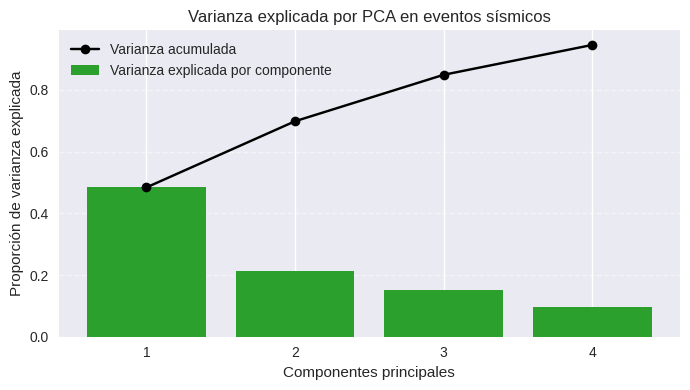

In [ ]:
# Visualización de la varianza explicada por los componentes principales
# Las variables originales son: magnitude, depth, cdi, mmi, sig

fig, ax = plt.subplots(figsize=(7, 4))
componentes = range(1, len(pca.explained_variance_ratio_) + 1)

ax.bar(
    componentes,
    pca.explained_variance_ratio_,
    color='tab:green',
    label='Varianza explicada por componente'
)
ax.plot(
    componentes,
    np.cumsum(pca.explained_variance_ratio_),
    marker='o',
    color='black',
    label='Varianza acumulada'
)

ax.set_xlabel('Componentes principales')
ax.set_ylabel('Proporción de varianza explicada')
ax.set_title('Varianza explicada por PCA en eventos sísmicos')
ax.set_xticks(componentes)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Este gráfico muestra cuánta información (varianza) de los eventos sísmicos se conserva al proyectarlos en los componentes principales.**

El primer componente suele capturar una combinación de magnitud, cdi y mmi (intensidad general del sismo).

El segundo componente a menudo refleja el efecto de la profundidad o la significancia geofísica.

En el dataset, es común que 2 componentes expliquen más del 90 % de la varianza total, lo que permite visualizar y analizar los perfiles sísmicos en 2D sin perder información crítica.

**14.1 Matriz de cargas**

La matriz de cargas (loadings) muestra cómo cada variable original —magnitude, depth, cdi, mmi y sig— contribuye a cada componente principal. Cada carga es el coeficiente de correlación entre una variable original y un componente, y permite interpretar el significado físico de los componentes.

**Ejemplo de lectura en contexto sísmico: **

Si el PC1 tiene cargas altas y positivas en magnitude, cdi y mmi, puede interpretarse como un eje de “intensidad general del sismo”, que combina magnitud física e impacto percibido.

Si el PC2 tiene una carga alta positiva en depth y negativa en cdi, podría representar un eje de “profundidad vs. percepción”, separando sismos profundos (poca percepción) de los superficiales (alta percepción).

Una carga alta de sig en PC1 o PC2 indicaría que la significancia geofísica está alineada con esos patrones físicos.

In [ ]:
# Matriz de cargas (loadings): contribución de cada variable sísmica a los componentes principales
# Cada fila representa un componente principal (PC1, PC2, ...)
# Cada columna muestra el peso (correlación) de una variable original en ese componente.

cargas_pca = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

display(cargas_pca)

,magnitude,depth,cdi,mmi,sig
PC1,0.310958,-0.395558,0.543024,0.567316,0.360718
PC2,0.611655,0.635076,0.027857,-0.192421,0.429831
PC3,-0.639530,0.073956,0.009556,-0.090154,0.759811
PC4,-0.335569,0.559643,0.667657,0.143788,-0.328256


**PC1** suele tener cargas altas en magnitude, cdi y mmi, lo que sugiere que representa un eje de "intensidad general del sismo" (combinación de magnitud física e impacto percibido).

**PC2** a menudo muestra una carga positiva en depth y negativa en cdi/mmi, interpretándose como un eje de "profundidad vs. percepción": sismos profundos (poca percepción) vs. superficiales (alta percepción).

**La variable sig** (significancia) puede aparecer en PC1 o PC2, indicando que está alineada con los patrones físicos dominantes.

Esta matriz es clave para interpretar físicamente los componentes y entender qué aspectos de los terremotos impulsan la variabilidad en los datos.

**15. Visualización en componentes principales**

El gráfico de dispersión (scatter plot) de las dos primeras componentes principales permite observar si los perfiles sísmicos identificados por K-Means forman agrupaciones visualmente coherentes una vez proyectados en un espacio de menor dimensionalidad. Esta visualización es especialmente útil porque combina toda la información de las cinco variables originales (magnitude, depth, cdi, mmi, sig) en solo dos ejes que capturan la mayor parte de la variabilidad.

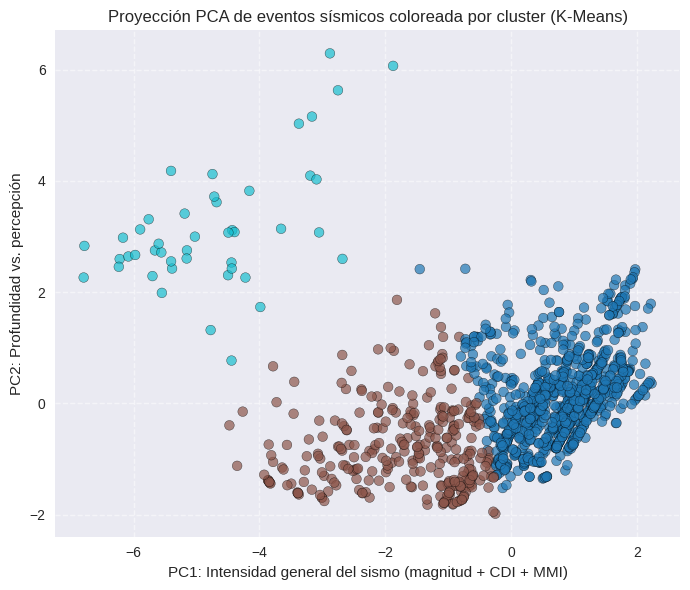

In [ ]:
# Visualización de eventos sísmicos en el espacio de los dos primeros componentes principales
# Coloreado según los clusters identificados por K-Means (perfiles sísmicos)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_pca[:, 0],  # Primer componente principal (PC1)
    X_pca[:, 1],  # Segundo componente principal (PC2)
    c=clusters,
    cmap='tab10',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

ax.set_xlabel('PC1: Intensidad general del sismo (magnitud + CDI + MMI)')
ax.set_ylabel('PC2: Profundidad vs. percepción')
ax.set_title('Proyección PCA de eventos sísmicos coloreada por cluster (K-Means)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**PC1** suele combinar magnitude, cdi y mmi, representando la intensidad general del evento.

**PC2** a menudo opone depth a las medidas de intensidad, capturando la relación entre profundidad y percepción en superficie.

Los clusters bien separados en este plano sugieren que los perfiles sísmicos (ej. “sismos superficiales de alto impacto”) son estructuras reales en los datos, no artefactos del ruido.

**Parte IV · Integración PCA + K-Means**
En el análisis de eventos sísmicos, aunque contamos con solo 5 variables, algunas están altamente correlacionadas (como cdi y mmi, ambas medidas de intensidad). Esta redundancia puede afectar la estabilidad del clustering al dar doble peso a un mismo concepto físico.

**Aplicar PCA antes de K-Means permite:**

Eliminar colinealidades y combinar información redundante en componentes ortogonales.

Resaltar las direcciones de mayor variabilidad en los datos sísmicos (por ejemplo, un eje que combina magnitud e intensidad, y otro que opone profundidad a percepción).

Mejorar la coherencia de los clusters, especialmente si el ruido o las escalas disparejas distorsionan las distancias euclidianas.

In [ ]:
# Pipeline integrado: escalado → PCA (2 componentes) → K-Means
# Este flujo combina preprocesamiento y clustering para identificar perfiles sísmicos
# en un espacio reducido que conserva la mayor parte de la variabilidad física.

pipeline = Pipeline(
    steps=[
        ('scaler', StandardScaler()),                     # Escala magnitude, depth, cdi, mmi, sig
        ('pca', PCA(n_components=2, random_state=42)),   # Reduce a 2 componentes principales
        ('kmeans', KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42))
    ]
)

# Ajustar el pipeline al conjunto de variables sísmicas
pipeline.fit(X)

# Extraer la proyección en los 2 componentes principales (para visualización)
X_pca_2 = pipeline.named_steps['pca'].transform(pipeline.named_steps['scaler'].transform(X))

# Obtener las etiquetas de cluster asignadas por K-Means en el espacio reducido
clusters_pca = pipeline.named_steps['kmeans'].labels_

print('Dimensiones tras PCA (pipeline):', X_pca_2.shape)

Dimensiones tras PCA (pipeline): (1300, 2)


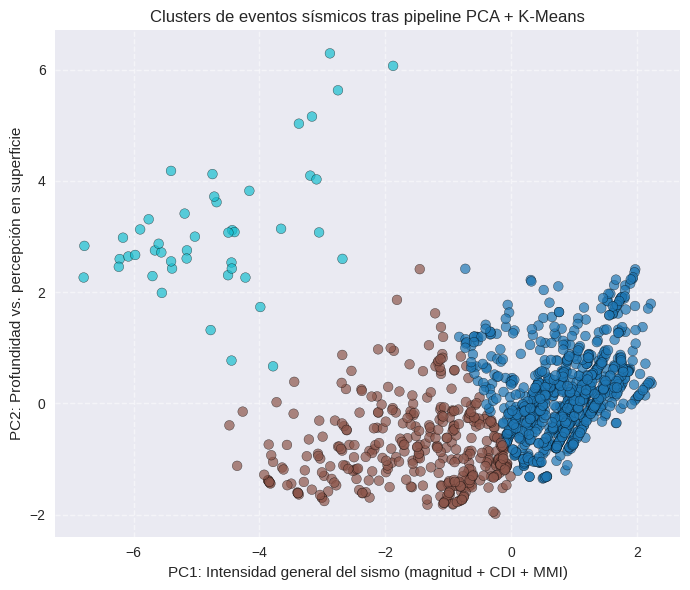

In [ ]:
# Visualización de los clusters de eventos sísmicos en el espacio reducido por PCA
# El pipeline aplica: escalado → PCA (2 componentes) → K-Means

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    X_pca_2[:, 0],  # Primer componente principal (PC1)
    X_pca_2[:, 1],  # Segundo componente principal (PC2)
    c=clusters_pca,
    cmap='tab10',
    alpha=0.7,
    edgecolor='k',
    linewidth=0.3
)

ax.set_xlabel('PC1: Intensidad general del sismo (magnitud + CDI + MMI)')
ax.set_ylabel('PC2: Profundidad vs. percepción en superficie')
ax.set_title('Clusters de eventos sísmicos tras pipeline PCA + K-Means')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**PC1** suele combinar magnitude, cdi y mmi, representando la intensidad general del evento.

**PC2** a menudo opone depth a las medidas de intensidad, capturando la relación entre profundidad y percepción.

**Los clusters bien separados en este espacio indican que el pipeline ha identificado perfiles sísmicos coherentes, como:**

Sismos superficiales de alto impacto (PC1 alta, PC2 baja),

Eventos profundos de baja percepción (PC1 baja, PC2 alta),

y posiblemente sismos extremos en zonas remotas (alta magnitud, CDI = 0).